## Post Processing

In [2]:
from pathlib import Path
from datetime import datetime
import re
import json
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "jupyter_notebooks" else Path.cwd()

# ============================================================================
# PATH & TIMESTAMP UTILITIES
# ============================================================================

def _as_project_path(path_like: str) -> Path:
    """Convert relative paths to project-root-relative paths."""
    p = Path(path_like)
    return p if p.is_absolute() else (PROJECT_ROOT / p)

def _ts_from_name(text: str):
    """Extract datetime (YYYYMMDD_HHMMSS) from filename."""
    m = re.search(r"(\d{8}_\d{6})", text)
    if not m:
        return None
    try:
        return datetime.strptime(m.group(1), "%Y%m%d_%H%M%S")
    except ValueError:
        return None

def _nearest_run_dir(parent: Path, ts: datetime):
    """Find the run directory on the same day with the nearest timestamp."""
    day_prefix = ts.strftime("%Y%m%d")
    run_dirs = sorted(parent.glob(f"cpmg_reopt_run_{day_prefix}_*"))
    if not run_dirs:
        return None

    best = None
    best_dt = None
    for run_dir in run_dirs:
        run_ts = _ts_from_name(run_dir.name)
        if run_ts is None:
            continue
        delta = abs((run_ts - ts).total_seconds())
        if best_dt is None or delta < best_dt:
            best = run_dir
            best_dt = delta
    return best

# ============================================================================
# HDF5 UTILITIES
# ============================================================================

def _collect_datasets(h5f: h5py.File):
    """Recursively collect all datasets from HDF5 file."""
    datasets = {}
    def visitor(name, obj):
        if isinstance(obj, h5py.Dataset):
            datasets[f"/{name}"] = np.asarray(obj[()])
    h5f.visititems(visitor)
    return datasets

def _find_series(datasets: dict, candidate_names):
    """Find first matching dataset by name."""
    for candidate in candidate_names:
        for key, value in datasets.items():
            if Path(key).name == candidate:
                return np.asarray(value)
    return None

def _resolve_chunk_files(path_like: str):
    """Return chunk h5 files for run folders, log files, or direct h5 paths."""
    p = _as_project_path(path_like)

    if p.is_dir():
        files = sorted(p.glob("*_chunk_*.h5"))
        if not files:
            files = sorted(p.glob("*chunk*.h5"))
        return files

    if p.is_file() and p.suffix.lower() == ".log":
        ts = _ts_from_name(p.stem)
        candidates = []
        if ts is not None:
            ts_str = ts.strftime("%Y%m%d_%H%M%S")
            candidates.append(p.parent / f"cpmg_reopt_run_{ts_str}")

        stem_candidate = p.stem.replace("terminal_", "")
        candidates.append(p.parent / stem_candidate)

        for candidate in candidates:
            if candidate.is_dir():
                files = sorted(candidate.glob("*_chunk_*.h5"))
                if files:
                    return files

        if ts is not None:
            nearest = _nearest_run_dir(p.parent, ts)
            if nearest is not None:
                files = sorted(nearest.glob("*_chunk_*.h5"))
                if files:
                    return files
        return []

    if p.is_file() and p.suffix.lower() in {".h5", ".hdf5"}:
        return [p]

    return []

# ============================================================================
# CORE LOADING: From Chunks or Combined Files
# ============================================================================

def load_run_data(run_path: str, verbose=True):
    """
    Load sweep data from a run (handles both combined h5 and chunk-based runs).
    
    Args:
        run_path: Path to run folder, combined h5, or log file
        verbose: Print status messages
    
    Returns:
        dict with keys:
            - tau_us: tau array in microseconds (sorted by chunk numerically)
            - data: list of dicts, each with keys:
                * chunk_id: simplified chunk number (0, 1, 2, ...)
                * signal: signal1 counts/s
                * reference: reference1 counts/s
                * contrast: signal/reference
                * source_file: original h5 filename
                * reps: repetition count for weighting
            - run_name: name of the run
            - mode: "combined" or "chunks"
    """
    run_path = _as_project_path(run_path)
    
    # Try combined h5 first if path is directory
    combined_h5 = None
    if run_path.is_dir():
        candidates = sorted(run_path.glob("*combined*.h5"))
        if candidates:
            combined_h5 = candidates[0]
    elif run_path.is_file() and run_path.suffix.lower() in {".h5", ".hdf5"}:
        combined_h5 = run_path
    
    # Load from combined file
    if combined_h5 is not None and combined_h5.exists():
        try:
            return _load_from_combined(combined_h5, verbose=verbose)
        except Exception as e:
            if verbose:
                print(f"  Combined file load failed ({e}), trying chunks...")
    
    # Fall back to chunks
    run_folder = run_path if run_path.is_dir() else run_path.parent
    return _load_from_chunks(run_folder, verbose=verbose)


def _load_from_combined(h5_path: Path, verbose=True):
    """Load from a single combined HDF5 file."""
    h5_path = Path(h5_path)
    
    with h5py.File(h5_path, "r") as h5f:
        datasets = _collect_datasets(h5f)
        
        tau = _find_series(datasets, ["tau_ns", "tau_ftns", "tau_tus", "tau_samples"])
        signal = _find_series(datasets, ["signal1_cts_s", "signal1"])
        reference = _find_series(datasets, ["reference1_cts_s", "reference1"])
    
    if tau is None or signal is None or reference is None:
        raise KeyError("Missing tau or signal/reference in combined file")
    
    tau = np.asarray(tau, dtype=float).ravel()
    if tau.min() < 100:
        tau_us = tau * 0.20345052083333334 / 1e3
    else:
        tau_us = tau / 1e3
    
    signal = np.asarray(signal, dtype=float).ravel()
    reference = np.asarray(reference, dtype=float).ravel()
    
    # Single "chunk" representing the entire combined file
    data = [{
        "chunk_id": 0,
        "signal": signal,
        "reference": reference,
        "contrast": signal / np.clip(reference, 1e-12, None),
        "source_file": h5_path.name,
        "reps": 1.0,
    }]
    
    if verbose:
        print(f"✓ Loaded from combined: {h5_path.name}")
    
    return {
        "tau_us": tau_us,
        "data": data,
        "run_name": h5_path.parent.name,
        "mode": "combined",
    }


def _load_from_chunks(run_folder: Path, verbose=True):
    """Load from chunk files in a run folder."""
    run_folder = Path(run_folder)
    chunk_files = _resolve_chunk_files(str(run_folder))
    
    if not chunk_files:
        raise FileNotFoundError(f"No chunk files found in {run_folder}")
    
    tau_ref = None
    data_list = []
    
    for chunk_idx, chunk_file in enumerate(chunk_files):
        try:
            with h5py.File(chunk_file, "r") as h5f:
                datasets = _collect_datasets(h5f)
                
                tau = _find_series(datasets, ["tau_ns", "tau_ftns", "tau_tus", "tau_samples"])
                signal = _find_series(datasets, ["signal1_cts_s", "signal1"])
                reference = _find_series(datasets, ["reference1_cts_s", "reference1"])
                
                if tau is None or signal is None or reference is None:
                    if verbose:
                        print(f"  ⚠ Skipping {chunk_file.name} (missing datasets)")
                    continue
                
                tau = np.asarray(tau, dtype=float).ravel()
                signal = np.asarray(signal, dtype=float).ravel()
                reference = np.asarray(reference, dtype=float).ravel()
                
                # Establish tau reference from first chunk
                if tau_ref is None:
                    if tau.min() < 100:
                        tau_us = tau * 0.20345052083333334 / 1e3
                    else:
                        tau_us = tau / 1e3
                    tau_ref = tau_us
                
                # Get reps
                reps = 1.0
                if "experiment" in h5f and hasattr(h5f["experiment"], "attrs"):
                    try:
                        reps = float(h5f["experiment"].attrs.get("reps", 1.0))
                    except (TypeError, ValueError):
                        reps = 1.0
                
                contrast = signal / np.clip(reference, 1e-12, None)
                
                data_list.append({
                    "chunk_id": chunk_idx,
                    "signal": signal,
                    "reference": reference,
                    "contrast": contrast,
                    "source_file": chunk_file.name,
                    "reps": reps,
                })
        
        except Exception as e:
            if verbose:
                print(f"  ⚠ Error loading {chunk_file.name}: {e}")
            continue
    
    if not data_list or tau_ref is None:
        raise RuntimeError(f"Could not load any valid chunks from {run_folder}")
    
    if verbose:
        print(f"✓ Loaded {len(data_list)} chunks from {run_folder.name}")
    
    return {
        "tau_us": tau_ref,
        "data": data_list,
        "run_name": run_folder.name,
        "mode": "chunks",
    }

# ============================================================================
# DATA INSPECTION & FILTERING
# ============================================================================

def summarize_chunks(run_data):
    """
    Print summary of chunk statistics.
    
    Args:
        run_data: dict from load_run_data()
    
    Returns:
        DataFrame with chunk statistics
    """
    rows = []
    for chunk in run_data["data"]:
        rows.append({
            "chunk_id": chunk["chunk_id"],
            "source_file": chunk["source_file"],
            "signal_mean": np.mean(chunk["signal"]),
            "signal_std": np.std(chunk["signal"], ddof=1) if len(chunk["signal"]) > 1 else 0.0,
            "reference_mean": np.mean(chunk["reference"]),
            "reference_std": np.std(chunk["reference"], ddof=1) if len(chunk["reference"]) > 1 else 0.0,
            "contrast_mean": np.mean(chunk["contrast"]),
            "reps": chunk["reps"],
        })
    
    df = pd.DataFrame(rows)
    print(f"\n{run_data['run_name']} ({run_data['mode']} mode) — {len(df)} chunk(s):")
    print(df.to_string(index=False))
    return df


def filter_chunks(run_data, chunk_ids=None, reference_min=None, reference_max=None):
    """
    Filter run data to include only selected chunks.
    
    Args:
        run_data: dict from load_run_data()
        chunk_ids: list of chunk_id values to keep (e.g., [0, 1, 2])
        reference_min: exclude chunks with reference_mean < this value
        reference_max: exclude chunks with reference_mean > this value
    
    Returns:
        Filtered run_data dict (same structure)
    """
    filtered_data = []
    
    for chunk in run_data["data"]:
        # Check chunk_id filter
        if chunk_ids is not None and chunk["chunk_id"] not in chunk_ids:
            continue
        
        # Check reference bounds
        ref_mean = np.mean(chunk["reference"])
        if reference_min is not None and ref_mean < reference_min:
            continue
        if reference_max is not None and ref_mean > reference_max:
            continue
        
        filtered_data.append(chunk)
    
    return {
        "tau_us": run_data["tau_us"],
        "data": filtered_data,
        "run_name": run_data["run_name"],
        "mode": run_data["mode"],
    }

# ============================================================================
# PLOTTING
# ============================================================================

def _aggregate_chunks(run_data):
    """
    Aggregate all chunks in run_data by summing with reps weighting.
    
    Args:
        run_data: dict from load_run_data()
    
    Returns:
        Tuple of (signal_agg, reference_agg, contrast_agg) arrays
    """
    if not run_data["data"]:
        raise ValueError("No chunks to aggregate")
    
    tau_len = len(run_data["tau_us"])
    signal_acc = np.zeros(tau_len, dtype=float)
    reference_acc = np.zeros(tau_len, dtype=float)
    weight_total = 0.0
    
    for chunk in run_data["data"]:
        reps = chunk.get("reps", 1.0)
        signal_acc += reps * chunk["signal"]
        reference_acc += reps * chunk["reference"]
        weight_total += reps
    
    # Average by total weight
    if weight_total > 0:
        signal_agg = signal_acc / weight_total
        reference_agg = reference_acc / weight_total
    else:
        signal_agg = signal_acc
        reference_agg = reference_acc
    
    contrast_agg = signal_agg / np.clip(reference_agg, 1e-12, None)
    
    return signal_agg, reference_agg, contrast_agg


def plot_sweep(run_data, title_suffix=""):
    """
    Plot aggregated sweep data (tau vs signal/reference) in microseconds.
    
    Aggregates all chunks using reps weighting before plotting.
    
    Args:
        run_data: dict from load_run_data() (optionally filtered)
        title_suffix: additional text for title
    """
    tau_us = run_data["tau_us"]
    signal_agg, reference_agg, contrast_agg = _aggregate_chunks(run_data)
    
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    
    # Plot 1: Aggregated Signal and Reference
    axes[0].plot(
        tau_us,
        signal_agg,
        "o-",
        lw=1.3,
        ms=4,
        alpha=0.85,
        color="#1f77b4",
        label="signal (aggregated)",
    )
    axes[0].plot(
        tau_us,
        reference_agg,
        "s-",
        lw=1.3,
        ms=3.5,
        alpha=0.85,
        color="#d62728",
        label="reference (aggregated)",
    )
    
    axes[0].set_ylabel("counts/s")
    axes[0].set_title(f"Signal & Reference {title_suffix}")
    axes[0].grid(alpha=0.3)
    axes[0].legend(fontsize=10, loc="best")
    
    # Plot 2: Aggregated Contrast
    axes[1].plot(
        tau_us,
        contrast_agg,
        "o-",
        lw=1.3,
        ms=4,
        alpha=0.85,
        color="#2b8cbe",
        label="contrast (aggregated)",
    )
    
    axes[1].set_xlabel("τ (µs)")
    axes[1].set_ylabel("signal / reference")
    axes[1].set_title(f"Contrast {title_suffix}")
    axes[1].grid(alpha=0.3)
    axes[1].legend(fontsize=10, loc="best")
    
    plt.tight_layout()
    plt.show()


In [3]:
%matplotlib widget


In [36]:
# Quick Start: Load & Plot a Run

# Edit the `run_path` below to point to any run folder, combined h5 file, or reopt log file.


In [37]:
# ============================================================================
# STEP 1: Load Run (combined or chunks)
# ============================================================================

# Edit this to point to your run:
run_path = r"data\cpmg_reopt\cpmg_reopt_run_20260331_182347"

# Load the run
run_data = load_run_data(run_path, verbose=True)
print(f"\nRun mode: {run_data['mode']}")
print(f"Tau range: {run_data['tau_us'].min():.3f} – {run_data['tau_us'].max():.3f} µs")
print(f"Num chunks: {len(run_data['data'])}")


  Combined file load failed ('Missing tau or signal/reference in combined file'), trying chunks...
✓ Loaded 50 chunks from cpmg_reopt_run_20260331_182347

Run mode: chunks
Tau range: 0.200 – 9.152 µs
Num chunks: 50


In [38]:
# ============================================================================
# STEP 2: Inspect & Filter Chunks
# ============================================================================

# Print statistics for all chunks
chunk_stats = summarize_chunks(run_data)

# Optional: Filter chunks by various criteria
# Examples:
#   - Keep only chunks 0, 1, 2:
#     filtered = filter_chunks(run_data, chunk_ids=[0, 1, 2])
#
#   - Exclude chunks with low reference counts (< 500):
#     filtered = filter_chunks(run_data, reference_min=500)
#
#   - Exclude chunks with high reference counts (> 1000):
#     filtered = filter_chunks(run_data, reference_max=1000)

# For now, use all chunks
filtered_run = run_data
print(f"\nUsing {len(filtered_run['data'])} chunks")



cpmg_reopt_run_20260331_182347 (chunks mode) — 50 chunk(s):
 chunk_id                               source_file  signal_mean  signal_std  reference_mean  reference_std  contrast_mean   reps
        0 cpmg_xy_fine_res_chunk_20260331_184159.h5  9491.798746 2778.303284    10067.654325    2861.632135       1.032841 2000.0
        1 cpmg_xy_fine_res_chunk_20260331_190047.h5 69536.045381 8274.840959    75775.926933    7906.328536       0.927775 2000.0
        2 cpmg_xy_fine_res_chunk_20260331_191935.h5 68180.204608 8187.083203    74016.393589    7925.564253       0.931602 2000.0
        3 cpmg_xy_fine_res_chunk_20260331_193822.h5 69489.465469 8472.039940    75612.440575    7891.522524       0.929209 2000.0
        4 cpmg_xy_fine_res_chunk_20260331_195710.h5 68647.830391 8336.221517    75276.791209    8128.655125       0.922349 2000.0
        5 cpmg_xy_fine_res_chunk_20260331_201558.h5 67707.098834 8026.708699    74021.416913    7734.424229       0.924739 2000.0
        6 cpmg_xy_fine_res_ch

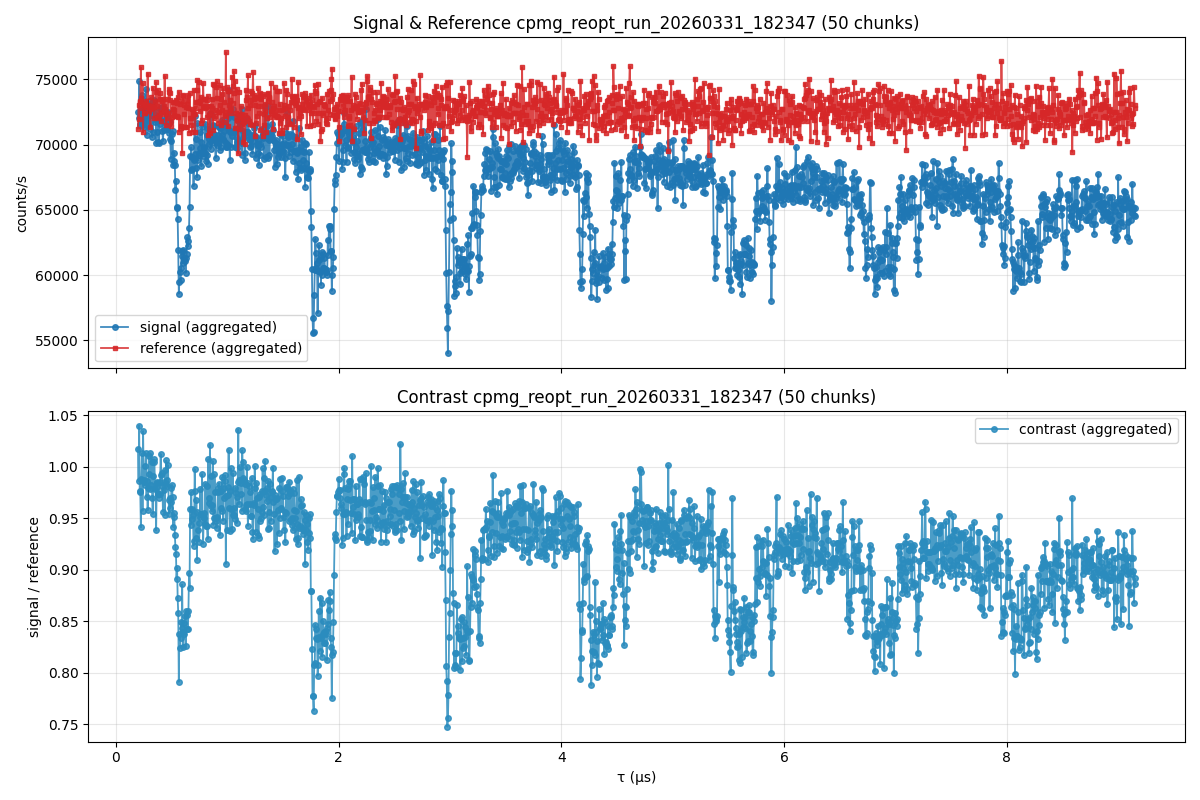

In [39]:
# ============================================================================
# STEP 3: Plot Sweep Data
# ============================================================================

# Plot with a title showing the run name and filtering applied
title = f"{filtered_run['run_name']}"
if filtered_run['mode'] == 'chunks':
    title += f" ({len(filtered_run['data'])} chunks)"

plot_sweep(filtered_run, title_suffix=title)


# Advanced: Filtering & Comparison


In [41]:
# Optional: Filter chunks by reference level (e.g., exclude noisy chunks)
# 
# Uncomment and edit one of the examples below:

# Example 1: Keep only chunks 0 and 1
# filtered_run = filter_chunks(run_data, chunk_ids=[0, 1])

# Example 2: Exclude chunks with low reference counts (< 500 counts/s)
# filtered_run = filter_chunks(run_data, reference_min=500)

# Example 3: Exclude chunks with high reference counts (> 1500 counts/s)
# filtered_run = filter_chunks(run_data, reference_max=1500)

# Example 4: Combine multiple filters
# filtered_run = filter_chunks(run_data, chunk_ids=[0, 1, 2, 3], reference_min=450)

# After filtering, replot:
# plot_sweep(filtered_run, title_suffix=f"{filtered_run['run_name']} (filtered)")


# Compare Multiple Runs


In [42]:
# Load and compare multiple runs
# Edit the run paths below:

runs_to_compare = {
    "run_A": r"data\cpmg_reopt\cpmg_reopt_run_20260324_222413",
    "run_B": r"data\cpmg_reopt\cpmg_reopt_run_20260326_224519",
    # "run_C": r"data\cpmg_reopt\cpmg_reopt_run_20260327_191002",
}

# Load all runs
comparison_data = {}
for label, path in runs_to_compare.items():
    try:
        comparison_data[label] = load_run_data(path, verbose=True)
    except Exception as e:
        print(f"✗ Failed to load {label}: {e}")

# Plot comparison (aggregated)
if comparison_data:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(comparison_data)))
    
    for (label, data), color in zip(comparison_data.items(), colors):
        tau_us = data["tau_us"]
        # Aggregate chunks
        signal_agg, reference_agg, contrast_agg = _aggregate_chunks(data)
        
        ax.plot(
            tau_us,
            contrast_agg,
            "o-",
            lw=1.5,
            ms=4,
            label=label,
            color=color,
            alpha=0.8,
        )
    
    ax.set_xlabel("τ (µs)")
    ax.set_ylabel("signal / reference")
    ax.set_title("Contrast Comparison (aggregated)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()


✗ Failed to load run_A: No chunk files found in c:\Users\QT3 User Facility\Documents\qick-dawg\data\cpmg_reopt
✗ Failed to load run_B: No chunk files found in c:\Users\QT3 User Facility\Documents\qick-dawg\data\cpmg_reopt


# Export Data


In [43]:
# Export filtered data to CSV
# Using the filtered_run from above

def export_to_csv(run_data, filename=None):
    """
    Export sweep data to CSV (tau_us, and per-chunk signal/reference/contrast).
    
    Args:
        run_data: dict from load_run_data()
        filename: output CSV filename (default: {run_name}_sweep.csv)
    """
    if filename is None:
        filename = f"{run_data['run_name']}_sweep.csv"
    
    tau_us = run_data["tau_us"]
    rows = []
    
    for chunk in run_data["data"]:
        for i, tau in enumerate(tau_us):
            rows.append({
                "tau_us": tau,
                "chunk_id": chunk["chunk_id"],
                "signal": chunk["signal"][i],
                "reference": chunk["reference"][i],
                "contrast": chunk["contrast"][i],
            })
    
    df = pd.DataFrame(rows)
    df.to_csv(filename, index=False)
    print(f"✓ Exported {len(df)} rows to {filename}")
    return df

# Example usage:
# df = export_to_csv(filtered_run)


In [47]:
C = 0.8414
A = 0.1547

In [52]:
def plot_sweep_0pop(run_data, title_suffix=""):
    """
    Plot aggregated sweep data (tau vs signal/reference) in microseconds.
    
    Aggregates all chunks using reps weighting before plotting.
    
    Args:
        run_data: dict from load_run_data() (optionally filtered)
        title_suffix: additional text for title
    """
    tau_us = run_data["tau_us"]
    signal_agg, reference_agg, contrast_agg = _aggregate_chunks(run_data)

    contrast_0pop = (contrast_agg - 0.8414) / (0.1547*2) + 0.5
    
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    
    # Plot 1: Aggregated Signal and Reference
    axes[0].plot(
        tau_us,
        signal_agg,
        "o-",
        lw=1.3,
        ms=4,
        alpha=0.85,
        color="#1f77b4",
        label="signal (aggregated)",
    )
    axes[0].plot(
        tau_us,
        reference_agg,
        "s-",
        lw=1.3,
        ms=3.5,
        alpha=0.85,
        color="#d62728",
        label="reference (aggregated)",
    )
    
    axes[0].set_ylabel("counts/s")
    axes[0].set_title(f"Signal & Reference {title_suffix}")
    axes[0].grid(alpha=0.3)
    axes[0].legend(fontsize=10, loc="best")
    
    # Plot 2: Aggregated Contrast
    axes[1].plot(
        tau_us,
        contrast_0pop,
        "o-",
        lw=1.3,
        ms=4,
        alpha=0.85,
        color="#2b8cbe",
        label="contrast (aggregated)",
    )
    
    axes[1].set_xlabel("τ (µs)")
    axes[1].set_ylabel("signal / reference")
    axes[1].set_title(f"Contrast {title_suffix}")
    axes[1].grid(alpha=0.3)
    axes[1].legend(fontsize=10, loc="best")
    
    plt.tight_layout()
    plt.show()


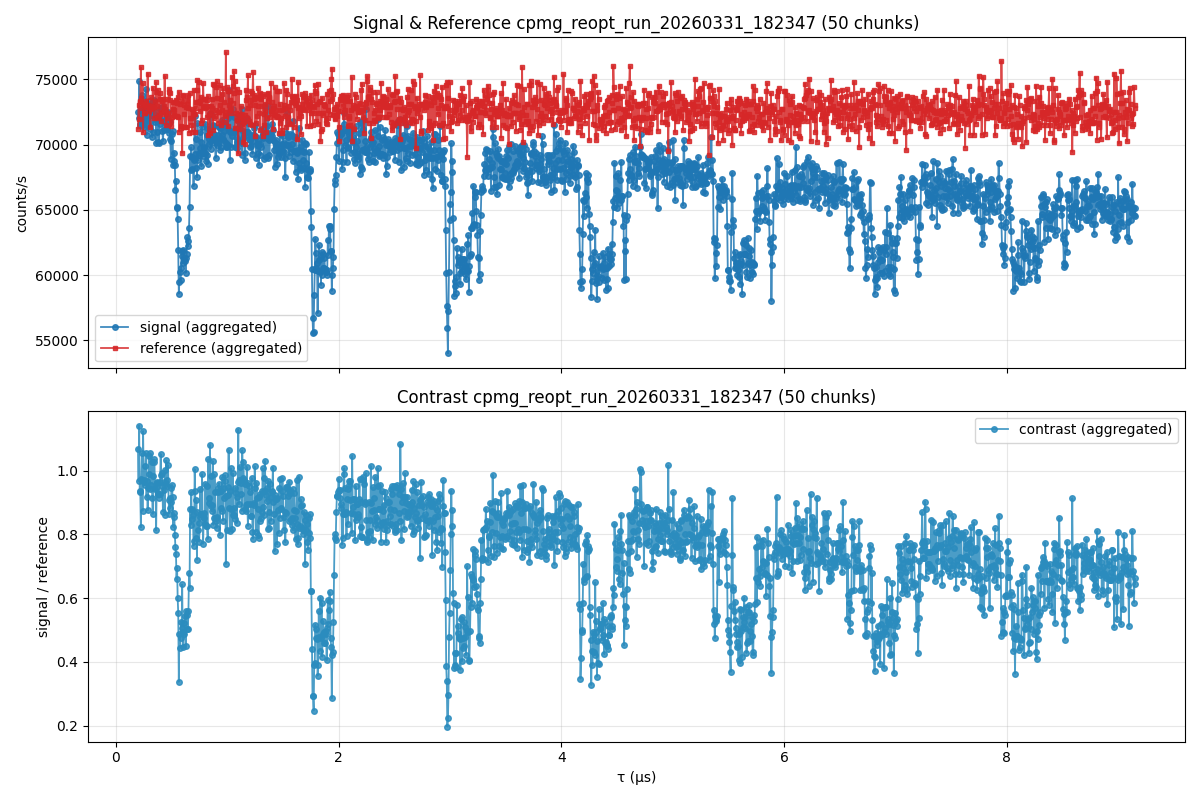

In [53]:
title = f"{filtered_run['run_name']}"
if filtered_run['mode'] == 'chunks':
    title += f" ({len(filtered_run['data'])} chunks)"

plot_sweep_0pop(filtered_run, title_suffix=title)


In [4]:
def _collect_datasets(h5f: h5py.File):
    """Recursively collect all datasets from HDF5 file."""
    datasets = {}
    def visitor(name, obj):
        if isinstance(obj, h5py.Dataset):
            datasets[f"/{name}"] = np.asarray(obj[()])
    h5f.visititems(visitor)
    return datasets

h5f = h5py.File(r"C:\Users\QT3 User Facility\Documents\qick-dawg\data\hahn_echo\hahn_echo_fine_res_run_20260406_012629\hahn_echo_fine_res_combined.h5", "r")
datasets = _collect_datasets(h5f)
for key in datasets:
    print(key)

/chunks/chunk_0000/data/contrast
/chunks/chunk_0000/data/reference1
/chunks/chunk_0000/data/reference1_cts_s
/chunks/chunk_0000/data/reference2
/chunks/chunk_0000/data/reference2_cts_s
/chunks/chunk_0000/data/signal1
/chunks/chunk_0000/data/signal1_cts_s
/chunks/chunk_0000/data/signal2
/chunks/chunk_0000/data/signal2_cts_s
/chunks/chunk_0000/data/sweep_pts
/chunks/chunk_0000/data/tau_ftns
/chunks/chunk_0000/data/tau_ftsamp
/chunks/chunk_0000/data/tau_ftus
/chunks/chunk_0001/data/contrast
/chunks/chunk_0001/data/reference1
/chunks/chunk_0001/data/reference1_cts_s
/chunks/chunk_0001/data/reference2
/chunks/chunk_0001/data/reference2_cts_s
/chunks/chunk_0001/data/signal1
/chunks/chunk_0001/data/signal1_cts_s
/chunks/chunk_0001/data/signal2
/chunks/chunk_0001/data/signal2_cts_s
/chunks/chunk_0001/data/sweep_pts
/chunks/chunk_0001/data/tau_ftns
/chunks/chunk_0001/data/tau_ftsamp
/chunks/chunk_0001/data/tau_ftus
/chunks/chunk_0002/data/contrast
/chunks/chunk_0002/data/reference1
/chunks/chun

In [46]:
target_keys = [
    "/data/contrast",
    "/data/signal1_cts_s",
    "/data/signal2_cts_s",
    "/data/tau_ftns",
]

extracted = {}

for target in target_keys:
    # 1) exact key (for combined-style datasets)
    if target in datasets:
        extracted[target] = np.asarray(datasets[target])
    else:
        # 2) suffix match (for chunked keys like /chunks/chunk_0000/data/...)
        matches = {k: np.asarray(v) for k, v in datasets.items() if k.endswith(target)}
        extracted[target] = matches if matches else None

# quick summary
for k, v in extracted.items():
    if isinstance(v, dict):
        print(f"{k}: {len(v)} chunk match(es)")
    elif v is None:
        print(f"{k}: not found")
    else:
        print(f"{k}: shape={v.shape}")


/data/contrast: shape=(72,)
/data/signal1_cts_s: shape=(72,)
/data/signal2_cts_s: shape=(72,)
/data/tau_ftns: shape=(72,)


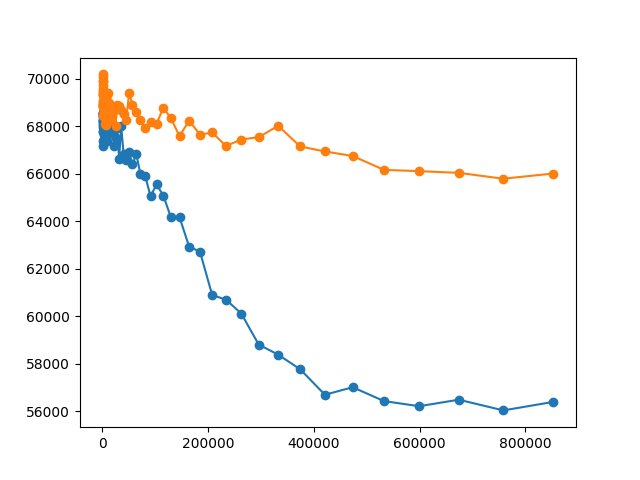

In [ ]:
plt.close('all')
plt.plot(extracted["/data/tau_ftns"], extracted["/data/signal1_cts_s"], "o-")
plt.plot(extracted["/data/tau_ftns"], extracted["/data/signal2_cts_s"], "o-")
plt.show()

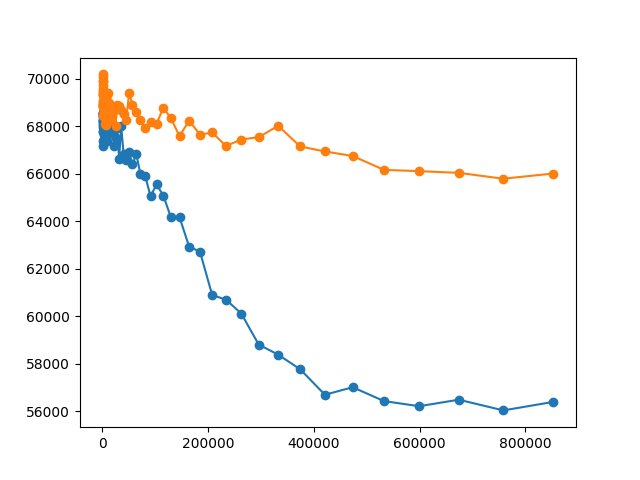

In [ ]:
plt.close('all')
plt.plot(np.asarray(datasets["/data/tau_ftns"]), extracted["/data/signal1_cts_s"], "o-")
plt.plot(np.asarray(datasets["/data/tau_ftns"]), extracted["/data/signal2_cts_s"], "o-")
plt.show()




In [54]:
def _collect_datasets(h5f: h5py.File):
    """Recursively collect all datasets from HDF5 file."""
    datasets = {}
    def visitor(name, obj):
        if isinstance(obj, h5py.Dataset):
            datasets[f"/{name}"] = np.asarray(obj[()])
    h5f.visititems(visitor)
    return datasets

h5f = h5py.File(r"C:\Users\QT3 User Facility\Documents\qick-dawg\data\t1\t1_fine_res_run_20260406_084902\t1_fine_res_combined.h5", "r")
datasets = _collect_datasets(h5f)
for key in datasets:
    print(key)

/chunks/chunk_0000/data/contrast
/chunks/chunk_0000/data/reference1
/chunks/chunk_0000/data/reference1_cts_s
/chunks/chunk_0000/data/reference2
/chunks/chunk_0000/data/reference2_cts_s
/chunks/chunk_0000/data/signal1
/chunks/chunk_0000/data/signal1_cts_s
/chunks/chunk_0000/data/signal2
/chunks/chunk_0000/data/signal2_cts_s
/chunks/chunk_0000/data/sweep_pts
/chunks/chunk_0000/data/t1_delay_tns
/chunks/chunk_0000/data/t1_delay_treg
/chunks/chunk_0000/data/t1_delay_tus
/chunks/chunk_0001/data/contrast
/chunks/chunk_0001/data/reference1
/chunks/chunk_0001/data/reference1_cts_s
/chunks/chunk_0001/data/reference2
/chunks/chunk_0001/data/reference2_cts_s
/chunks/chunk_0001/data/signal1
/chunks/chunk_0001/data/signal1_cts_s
/chunks/chunk_0001/data/signal2
/chunks/chunk_0001/data/signal2_cts_s
/chunks/chunk_0001/data/sweep_pts
/chunks/chunk_0001/data/t1_delay_tns
/chunks/chunk_0001/data/t1_delay_treg
/chunks/chunk_0001/data/t1_delay_tus
/chunks/chunk_0002/data/contrast
/chunks/chunk_0002/data/r

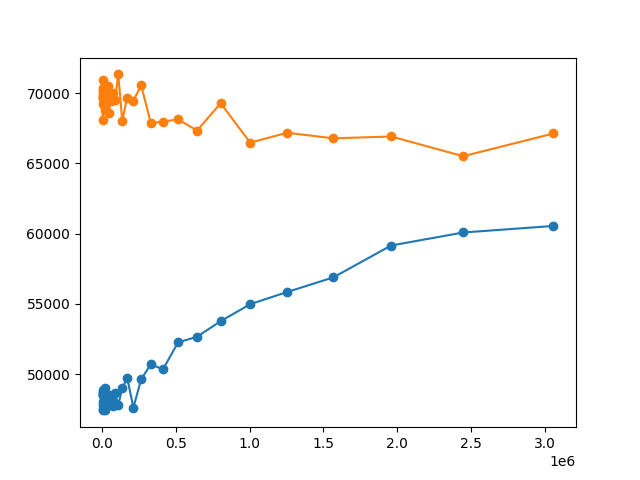

In [57]:
plt.close('all')
plt.plot(np.asarray(datasets["/data/t1_delay_tns"]), np.asarray(datasets["/data/signal1_cts_s"]), "o-")
plt.plot(np.asarray(datasets["/data/t1_delay_tns"]), np.asarray(datasets["/data/signal2_cts_s"]), "o-")
plt.show()